# Q9 — Do pricier restaurants rate higher or more consistently? *(extended)*

Uses the normalized `price_tier` (1 = cheapest … 4 = most expensive), derived from
Tripadvisor's band, Google's level, or TheFork's average EUR price.

In [1]:
from analysis.notebook import *

Connected to ClickHouse db='dataman' at localhost:8123


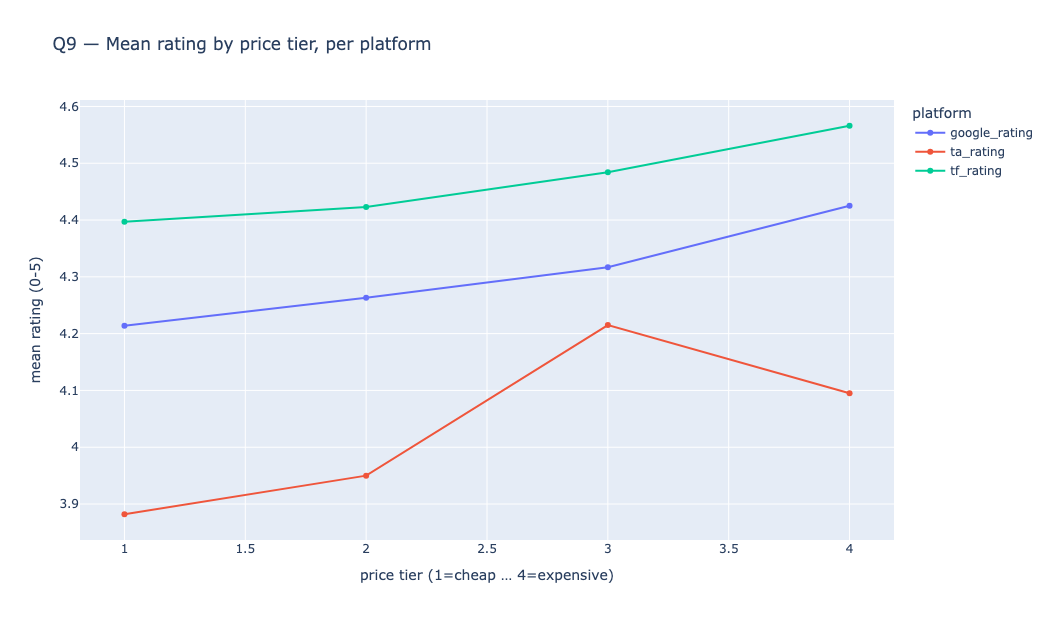

,price_tier,restaurants,google_rating,ta_rating,tf_rating,mean_rating,mean_range
0,1,2262,4.214,3.882,4.397,4.123,0.515
1,2,3120,4.263,3.950,4.423,4.166,0.469
2,3,83,4.317,4.215,4.484,4.332,0.379
3,4,232,4.425,4.095,4.566,4.295,0.447


In [2]:
q9 = publish(run(queries.q9_price_tier()), "q9_price_vs_rating",
             "Q9 — Per-platform rating and cross-platform spread by price tier.")
long = q9.melt(id_vars="price_tier", value_vars=["google_rating", "ta_rating", "tf_rating"],
               var_name="platform", value_name="rating")
fig = px.line(long, x="price_tier", y="rating", color="platform", markers=True,
              labels={"price_tier": "price tier (1=cheap … 4=expensive)", "rating": "mean rating (0-5)"},
              title="Q9 — Mean rating by price tier, per platform")
fig.show()
q9

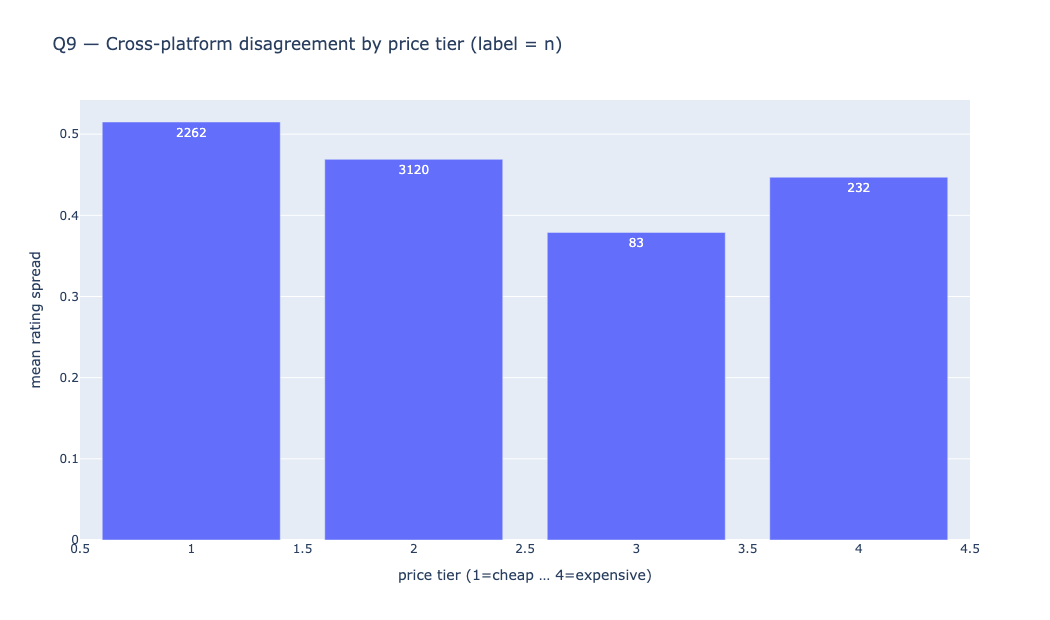

In [3]:
fig = px.bar(q9, x="price_tier", y="mean_range", text="restaurants",
             labels={"price_tier": "price tier (1=cheap … 4=expensive)", "mean_range": "mean rating spread"},
             title="Q9 — Cross-platform disagreement by price tier (label = n)")
fig.show()

**Answer (Q9):** Higher price tiers tend to be **rated higher and disagree less** —
`mean_rating` rises and `mean_range` falls toward the pricier tiers (with the caveat that
the most expensive tiers are small samples). Pricier venues appear to offer a more
consistent, better-regarded experience across platforms.